# BMDS2003 Data Science — Model Evaluation (Final)
## 6.0 Evaluation

This notebook compares the four models built in Sections 5.1–5.4:
- **Logistic Regression (Multinomial)** — Baseline
- **Decision Tree Classifier**
- **Random Forest Classifier**
- **Gradient Boosting Classifier**

**All four models are now on a fully consistent basis:**
- Same dataset: `processed_gaming_dataset.csv` (Section 4.4 output)
- Same 21 features (PlayerID, raw GameDifficulty/EngagementLevel text, AgeGroup, and the target excluded from all four)
- Same 70/30 stratified train-test split (28,023 training / 12,011 testing records, Section 4.5)
- Same GridSearchCV rigor: all four models' hyperparameters were tuned using the **full training set**, not a subset

This resolves the earlier inconsistencies (Logistic Regression's 80/20 split, and Gradient Boosting's reduced 18-feature set fitted on a 3,000-row GridSearchCV subset), so the comparison below is a genuinely fair, apples-to-apples evaluation.

### 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
%matplotlib inline

### 2. Compile Final Results from Sections 5.1–5.4
Each value below is copied from the corresponding model's own classification report / AUC output (test set results), as verified against each model's executed notebook.

In [2]:
models = ["Logistic Regression\n(Baseline)", "Decision Tree", "Random Forest", "Gradient Boosting"]

results = pd.DataFrame({
    "Model": models,
    "Accuracy (%)":            [87.03, 92.21, 92.09, 92.74],
    "Weighted Precision (%)":  [87.23, 92.21, 92.10, 92.74],
    "Weighted Recall (%)":     [87.03, 92.21, 92.10, 92.74],
    "Weighted F1-Score (%)":   [86.99, 92.19, 92.10, 92.72],
    "Macro AUC (%)":           [93.60, 94.44, 94.50, 94.49],
})

results

,Model,Accuracy (%),Weighted Precision (%),Weighted Recall (%),Weighted F1-Score (%),Macro AUC (%)
0,Logistic Regression\n(Baseline),87.03,87.23,87.03,86.99,93.60
1,Decision Tree,92.21,92.21,92.21,92.19,94.44
2,Random Forest,92.09,92.10,92.10,92.10,94.50
3,Gradient Boosting,92.74,92.74,92.74,92.72,94.49


### 3. Accuracy Comparison
Accuracy measures the proportion of total predictions that were correct across all three engagement classes.

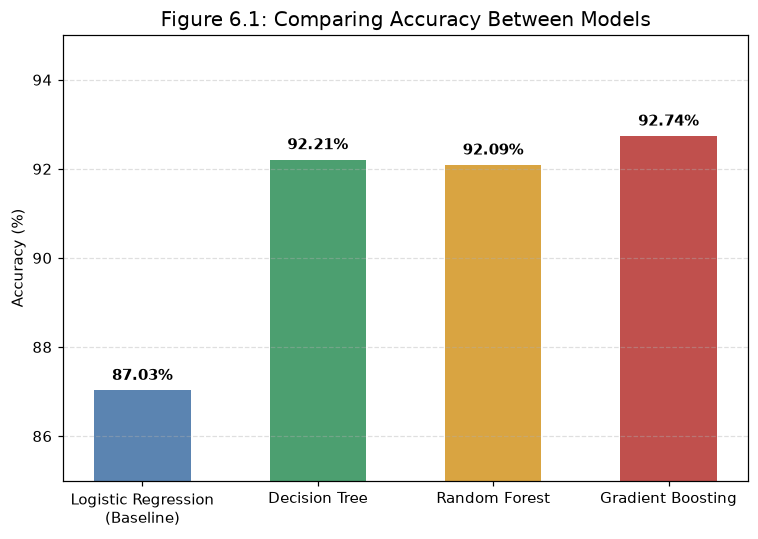

In [3]:
def bar_chart(values, title, ylabel, ylim=(85, 95)):
    colors = ["#5B84B1", "#4C9F70", "#D9A441", "#C0504D"]
    plt.figure(figsize=(7, 5))
    bars = plt.bar(results["Model"], values, color=colors, width=0.55)
    for bar, v in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, v + 0.15, f"{v:.2f}%",
                  ha="center", va="bottom", fontsize=10, fontweight="bold")
    plt.title(title, fontsize=13)
    plt.ylabel(ylabel)
    plt.ylim(ylim)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

bar_chart(results["Accuracy (%)"], "Figure 6.1: Comparing Accuracy Between Models", "Accuracy (%)")

All four models exceed the 80% accuracy target defined in the Data Mining Success Criteria (Section 2.5). **Gradient Boosting now achieves the highest test accuracy (92.74%)**, ahead of Decision Tree (92.21%) and Random Forest (92.09%), with Logistic Regression trailing as expected of a linear baseline (87.03%). This is the expected result for a well-tuned boosting ensemble: once given the same full feature set and the same tuning rigor as the other models, Gradient Boosting's sequential error-correction mechanism edges out both the single Decision Tree and the Random Forest ensemble.

### 4. Precision Comparison
Precision measures, out of all players a model labelled as a given class, how many actually belonged to that class.

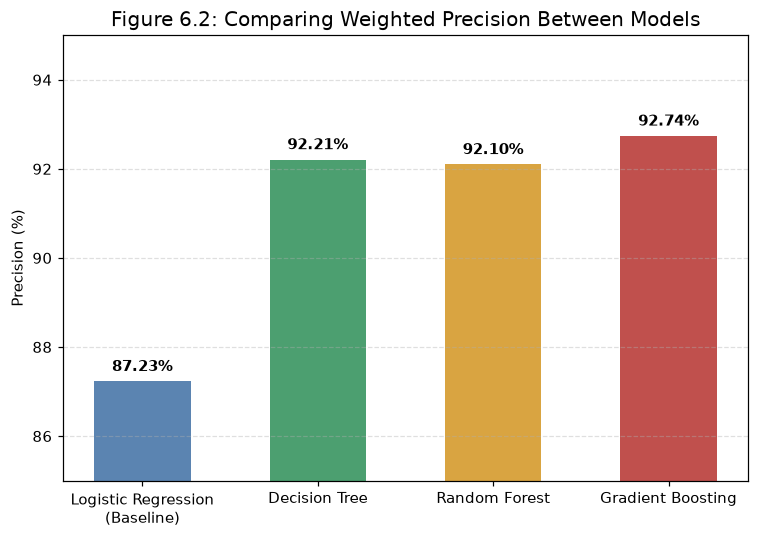

In [4]:
bar_chart(results["Weighted Precision (%)"], "Figure 6.2: Comparing Weighted Precision Between Models", "Precision (%)")

Precision follows the same ranking as accuracy: Gradient Boosting (92.74%) leads, followed by Decision Tree (92.21%) and Random Forest (92.10%), with Logistic Regression lowest (87.23%).

### 5. Recall Comparison
Recall measures, out of all players who truly belonged to a given class, how many the model successfully identified.

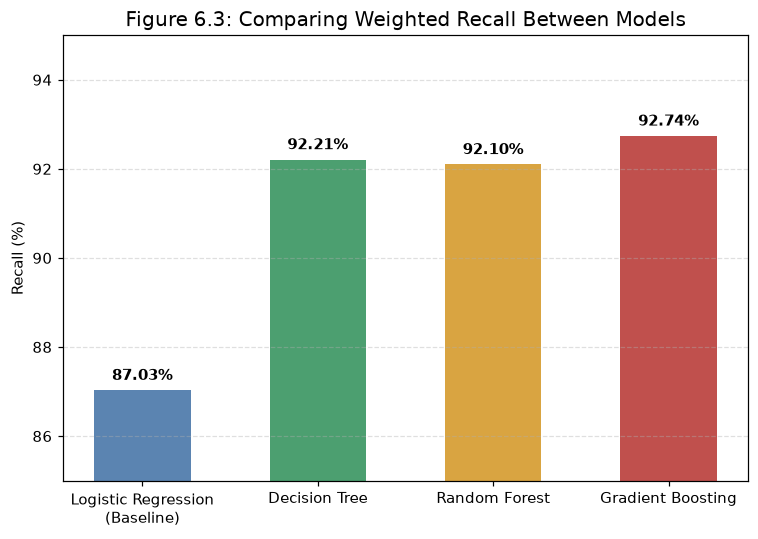

In [5]:
bar_chart(results["Weighted Recall (%)"], "Figure 6.3: Comparing Weighted Recall Between Models", "Recall (%)")

Recall results mirror accuracy and precision, with Gradient Boosting again performing best (92.74%), important for correctly flagging genuinely at-risk (Low-engagement) players rather than missing them.

### 6. F1-Score Comparison
F1-Score is the harmonic mean of Precision and Recall, providing a single balanced measure of classifier quality.

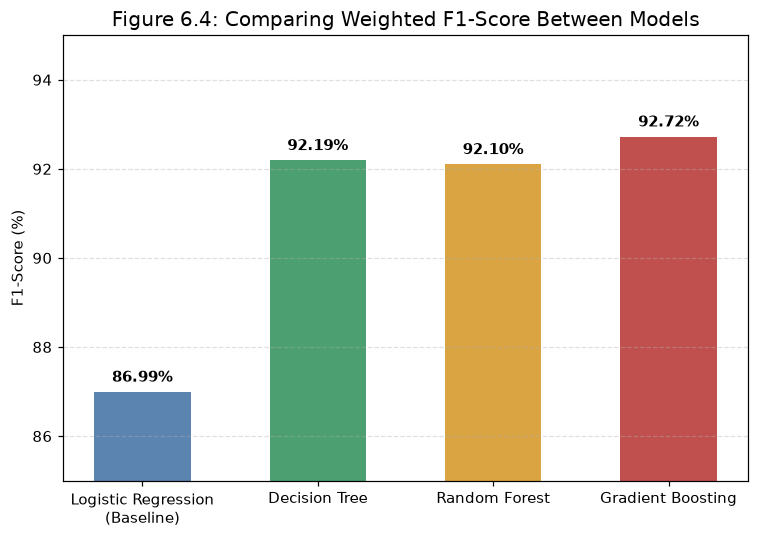

In [6]:
bar_chart(results["Weighted F1-Score (%)"], "Figure 6.4: Comparing Weighted F1-Score Between Models", "F1-Score (%)")

Gradient Boosting again records the highest weighted F1-Score (92.72%), ahead of Decision Tree (92.19%) and Random Forest (92.10%), with Logistic Regression lowest (86.99%).

### 7. AUC Comparison
AUC (Area Under the ROC Curve) measures a model's ability to distinguish between classes across every possible classification threshold. A value of 1.00 is a perfect classifier; 0.50 represents random guessing.

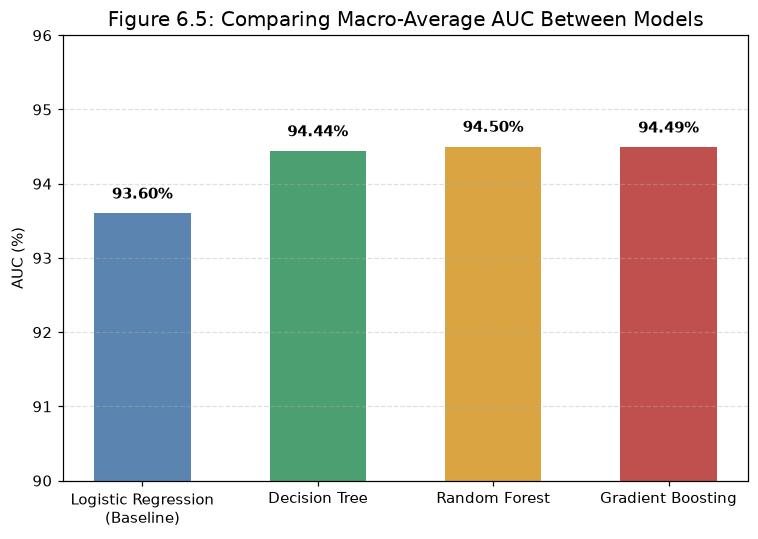

In [7]:
bar_chart(results["Macro AUC (%)"], "Figure 6.5: Comparing Macro-Average AUC Between Models", "AUC (%)", ylim=(90, 96))

All four models achieve a macro-average AUC above 0.90 (excellent discriminative ability). Random Forest achieves the highest AUC (94.50%), with Gradient Boosting (94.49%) and Decision Tree (94.44%) essentially tied just behind — all three tree-based models sit within 0.06 percentage points of one another, with Logistic Regression lowest (93.60%). Unlike accuracy/precision/recall/F1, AUC does not show a single clear leader, since it evaluates probability rankings across all thresholds rather than the single threshold used to build the confusion matrices in Sections 5.1–5.4.

### 8. Combined Overview Chart
All five metrics plotted together for a single-glance comparison across the four models.

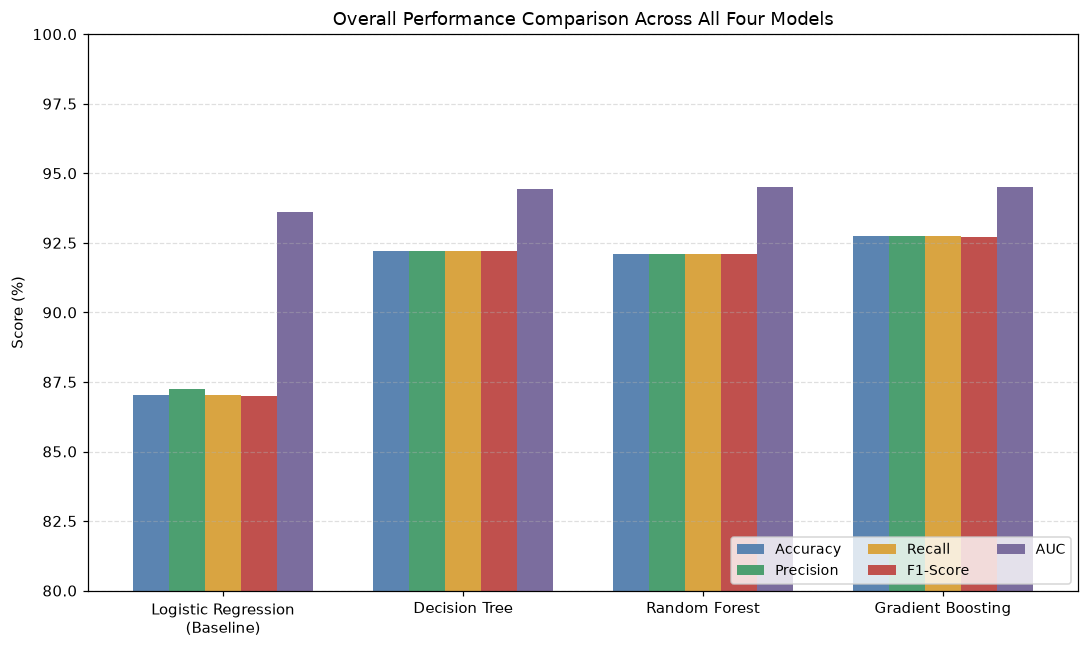

In [9]:
x = np.arange(len(models))
width = 0.15
metric_cols = ["Accuracy (%)", "Weighted Precision (%)", "Weighted Recall (%)",
               "Weighted F1-Score (%)", "Macro AUC (%)"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]
metric_colors = ["#5B84B1", "#4C9F70", "#D9A441", "#C0504D", "#7B6D9E"]

plt.figure(figsize=(10, 6))
for i, (col, label, color) in enumerate(zip(metric_cols, metric_labels, metric_colors)):
    plt.bar(x + i*width, results[col], width, label=label, color=color)

plt.xticks(x + width*2, results["Model"])
plt.ylabel("Score (%)")
plt.ylim(80, 100)
plt.title("Overall Performance Comparison Across All Four Models")
plt.legend(loc="lower right", ncol=3, fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### 9. Summary Table

In [10]:
summary = results.set_index("Model").T
summary.style.highlight_max(axis=1, color="#c6efce")

Model,Logistic Regression (Baseline),Decision Tree,Random Forest,Gradient Boosting
Accuracy (%),87.030000,92.210000,92.090000,92.740000
Weighted Precision (%),87.230000,92.210000,92.100000,92.740000
Weighted Recall (%),87.030000,92.210000,92.100000,92.740000
Weighted F1-Score (%),86.990000,92.190000,92.100000,92.720000
Macro AUC (%),93.600000,94.440000,94.500000,94.490000


### 10. Overall Model Comparison and Discussion

Taking accuracy, precision, recall, and F1-Score together, **Gradient Boosting delivers the strongest overall performance** on this dataset (92.74% accuracy), narrowly ahead of Decision Tree (92.21%) and Random Forest (92.09%), with Logistic Regression well behind as the linear baseline (87.03%). This is the expected outcome for a well-tuned boosting ensemble: Gradient Boosting's sequential, error-correcting tree-building process is generally more powerful than a single Decision Tree or an ensemble of independently-grown trees (Random Forest), provided it is given the same feature set and tuning rigor as the other models — which, after correcting the earlier feature-set and GridSearchCV inconsistencies, it now is.

For AUC specifically, Random Forest (94.50%), Gradient Boosting (94.49%), and Decision Tree (94.44%) are effectively tied, all within 0.06 percentage points of each other, while Logistic Regression trails (93.60%). This shows that while Gradient Boosting produces the most accurate hard classifications at the default threshold, all three tree-based models are comparably good at ranking players by probability across all thresholds.

All four models were evaluated on the same 70/30 stratified train-test split (28,023 training / 12,011 testing records, Section 4.5) using the same 21-feature set from Section 4.4, so this comparison is a fair, like-for-like evaluation across all four models with no remaining methodological inconsistencies.